# Tree simulation: independent or joint cEBMF?

**Start here:** select your **cebmf** Python kernel, then choose **Restart Kernel and Run All**.
The default example takes about a minute on CPU; timing depends on your computer.
All code is in this notebook. No files, helper scripts or GPU are needed.

If the package is not installed in that kernel, run these commands once in your
Anaconda terminal, then restart the notebook kernel:

```bat
conda activate cebmf
cd C:\Document\Serieux\Travail\python_work\package\cebmf_torch
python -m pip install -e . matplotlib ipykernel
python -m ipykernel install --user --name cebmf --display-name "Python (cebmf)"
```

We will generate a small tree, fit two models, and compare their predictions and
objectives. A hierarchy is useful only if it helps with the quantity we care about.

## 1. Imports and settings

Keep these defaults for the first run. Change settings here and run all cells again.

In [1]:
import time
import torch
import matplotlib.pyplot as plt
from cebmf_torch import cEBMF

# Data: rows are samples; columns are features.
SEED = 1
N, P = 300, 80
NOISE_SD = 1.25
K = 10                        # Starting number of factors; initialization may prune.
HOLDOUT_FRACTION = 0.02

# Fitting: CPU only for the current joint sampler.
BASELINE_ITERATIONS = 30
LEARNING_ROUNDS = 8
SAMPLER_SETTINGS = dict(
    initialization_iterations=5,
    pretrain_steps=50,
    sweeps_per_round=10,
    steps=30,
    burnin=100,
    draws=200,
    thin=1,
    seed=SEED + 100,
    progress_every=50,
)

torch.manual_seed(SEED)
torch.set_num_threads(1)
plt.rcParams.update({"font.size": 11})
print(f"Ready: {N} samples, {P} features, CPU.")

Ready: 300 samples, 80 features, CPU.


## 2. Make the tree and the noisy data

Each sample has a root program, one branch program and one leaf program.
The seven programs have different sparse feature patterns, which can be positive or negative.

```text
Root (all samples)
├── Left branch (30%)
│   ├── Leaf 1 (10%)
│   └── Leaf 2 (20%)
└── Right branch (70%)
    ├── Leaf 3 (50%)
    └── Leaf 4 (20%)
```

The signal is `L_true @ F_true.T`. We add independent Gaussian noise to get `Y`.

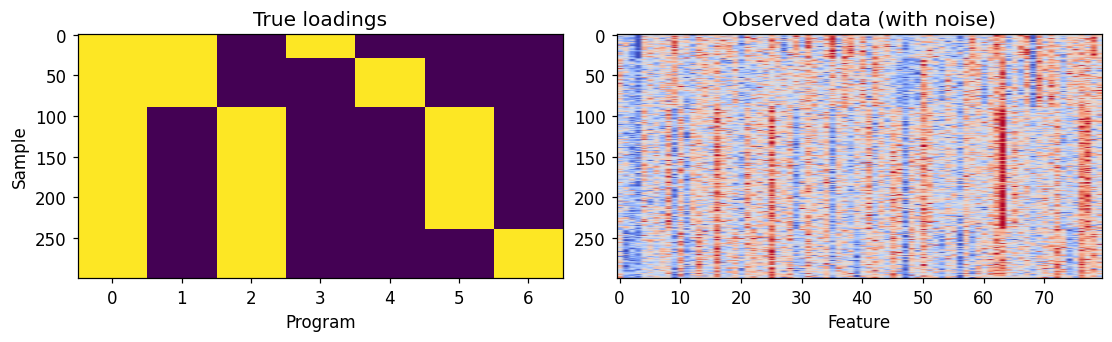

In [2]:
rng = torch.Generator().manual_seed(SEED)
feature_mask = torch.randint(0, 2, (P, 7), generator=rng).double()
F_true = feature_mask * torch.randn(P, 7, generator=rng, dtype=torch.float64)

L_true = torch.zeros(N, 7, dtype=torch.float64)
a, b, c = int(0.1 * N), int(0.3 * N), int(0.8 * N)
L_true[:, 0] = 1               # Root
L_true[:b, 1] = 1              # Left branch
L_true[b:, 2] = 1              # Right branch
L_true[:a, 3] = 1              # Leaf 1
L_true[a:b, 4] = 1             # Leaf 2
L_true[b:c, 5] = 1             # Leaf 3
L_true[c:, 6] = 1              # Leaf 4

X_true = L_true @ F_true.T
Y = X_true + NOISE_SD * torch.randn(N, P, generator=rng, dtype=torch.float64)

fig, axes = plt.subplots(1, 2, figsize=(10, 3), layout="constrained")
axes[0].imshow(L_true, aspect="auto", interpolation="nearest", cmap="viridis")
axes[0].set(title="True loadings", xlabel="Program", ylabel="Sample")
axes[1].imshow(Y, aspect="auto", cmap="coolwarm", vmin=-4, vmax=4)
axes[1].set(title="Observed data (with noise)", xlabel="Feature")
plt.show()

## 3. Hide some measurements

Both models receive the same matrix, with 2% of entries hidden as `NaN`.
We will use those entries to assess prediction. The true factors are never passed to a fit.

In [3]:
holdout_rng = torch.Generator().manual_seed(SEED + 400)
held_out = torch.rand(N, P, generator=holdout_rng) < HOLDOUT_FRACTION
Y_train = Y.clone()
Y_train[held_out] = torch.nan

def rmse(prediction, target, mask=None):
    error = prediction - target
    if mask is not None:
        error = error[mask]
    return error.square().mean().sqrt().item()

print(f"Hidden measurements: {held_out.sum().item()} / {Y.numel()}")

Hidden measurements: 463 / 24000


## 4. Fit the independent baseline

`prior_L="norm"` and `prior_F="norm"` use independent Gaussian-mixture priors.
We run 30 iterations and save the negative ELBO at each iteration to plot later.
Both models know the simulation's noise SD through `S=NOISE_SD`.

In [4]:
baseline = cEBMF(
    data=Y_train, K=K, prior_L="norm", prior_F="norm",
    S=NOISE_SD, device="cpu",
)
baseline.initialise_factors()

baseline_loss = []
started = time.perf_counter()
for iteration in range(BASELINE_ITERATIONS):
    baseline.iter_once()
    baseline_loss.append(baseline.obj[-1])

baseline_prediction = baseline.L @ baseline.F.T
print(f"Baseline finished in {time.perf_counter() - started:.1f} seconds.")
print(f"Retained factors: {baseline.model.K}")

Baseline finished in 3.6 seconds.
Retained factors: 5


## 5. Fit the joint loading hierarchy

The key change is **`prior_L="cgb", self_row_cov=True`**. For each factor, a neural
network uses earlier loadings to predict the probability of an active loading:
$L_{ik}\mid L_{i,<k}$. The joint sampler accounts for how changing a loading affects
its children. The CGB active component is Gaussian; loadings are not constrained to 0/1.

`fit(LEARNING_ROUNDS)` learns the neural priors, runs burn-in, then collects posterior
draws. Rank, noise and the independent feature prior stay fixed after initialization.
The warning explaining this behavior is expected.

**Use `result.reconstruction` for prediction:** this averages `L @ F.T` within draws.
Multiplying the separate posterior means of `L` and `F` generally gives a different answer.

In [5]:
joint = cEBMF(
    data=Y_train, K=K,
    prior_L="cgb", prior_F="norm",
    self_row_cov=True,
    S=NOISE_SD, device="cpu",
    joint_kwargs=SAMPLER_SETTINGS,
)
joint.initialise_factors()

started = time.perf_counter()
result = joint.fit(LEARNING_ROUNDS)
joint_prediction = result.reconstruction
print(f"Joint fit finished in {time.perf_counter() - started:.1f} seconds.")
print(f"Retained factors: {joint.model.K}")

C:\Document\Serieux\Travail\python_work\package\cebmf_torch\src\cebmf_torch\cebmf\cebmf.py:257: UserWarning: Self-covariates selected joint sampling. fit(maxit) now uses maxit prior-learning rounds, then burn-in and retained draws from joint_kwargs. Rank, noise and non-neural priors stay fixed; history_obj records sampled log joint densities, not an ELBO.
  self._ensure_joint_sampler()
Joint sweep 50/300; kept 0 draws
Joint sweep 100/300; kept 0 draws
Joint sweep 150/300; kept 50 draws
Joint sweep 200/300; kept 100 draws
Joint sweep 250/300; kept 150 draws
Joint sweep 300/300; kept 200 draws
Joint fit finished in 22.3 seconds.
Retained factors: 8


## 6. Did the prediction improve?

**Signal RMSE** measures recovery of the noiseless matrix. We can calculate it only
because this is a simulation. **Held-out RMSE** measures prediction of the hidden,
noisy observations. Lower is better for both.

Noise SD is 1.25, so noise contributes most of the held-out error. Better signal
recovery can coexist with slightly worse held-out RMSE on one finite test set.

In [6]:
print(f"{'Model':<20} {'Signal RMSE':>13} {'Held-out RMSE':>15}")
for name, prediction in [("Independent", baseline_prediction), ("Joint", joint_prediction)]:
    signal_error = rmse(prediction, X_true)
    test_error = rmse(prediction, Y, held_out)
    print(f"{name:<20} {signal_error:13.4f} {test_error:15.4f}")

signal_gain = 100 * (1 - rmse(joint_prediction, X_true) / rmse(baseline_prediction, X_true))
test_gain = 100 * (1 - rmse(joint_prediction, Y, held_out) / rmse(baseline_prediction, Y, held_out))
print(f"\nSignal RMSE reduction:   {signal_gain:+.1f}%")
print(f"Held-out RMSE reduction: {test_gain:+.1f}% (negative means worse)")

Model                  Signal RMSE   Held-out RMSE
Independent                 0.2452          1.2539
Joint                       0.2057          1.2588

Signal RMSE reduction:   +16.1%
Held-out RMSE reduction: -0.4% (negative means worse)


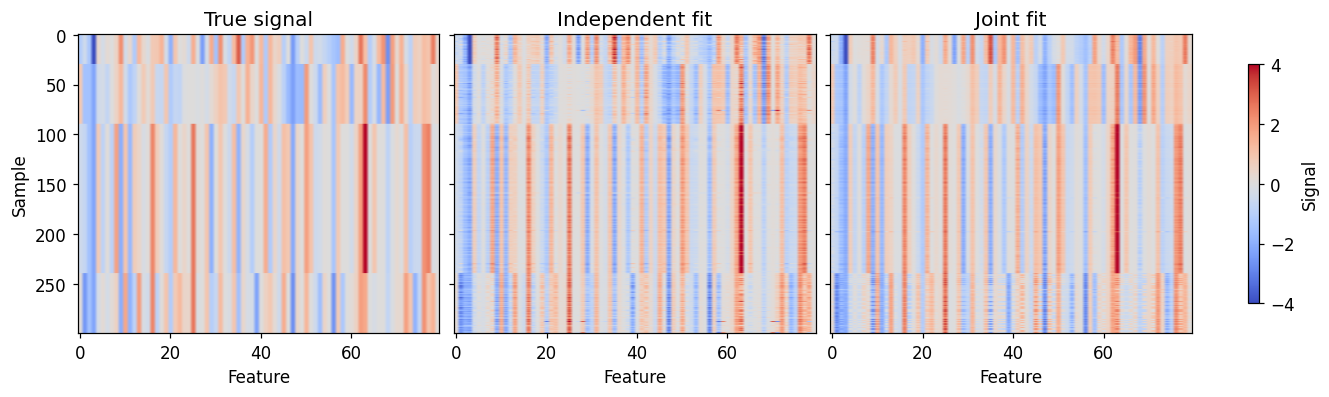

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True, layout="constrained")
for ax, prediction, title in zip(
    axes,
    [X_true, baseline_prediction, joint_prediction],
    ["True signal", "Independent fit", "Joint fit"],
):
    picture = ax.imshow(prediction, aspect="auto", cmap="coolwarm", vmin=-4, vmax=4)
    ax.set(title=title, xlabel="Feature")
axes[0].set_ylabel("Sample")
fig.colorbar(picture, ax=axes.tolist(), shrink=0.8, label="Signal")
plt.show()

## 7. Check the objectives

- **Left:** the independent model's negative ELBO. Lower is better.
- **Right:** the joint model's prior-learning loss, before and after each round's
  parameter update. Each pair uses the same latent draws, so the update should reduce
  this loss. New draws are used in the next round.

These are different objectives with different scales. The current joint solver does
**not** evaluate a marginal likelihood or joint ELBO. A decreasing prior-learning
loss alone does not establish better prediction.

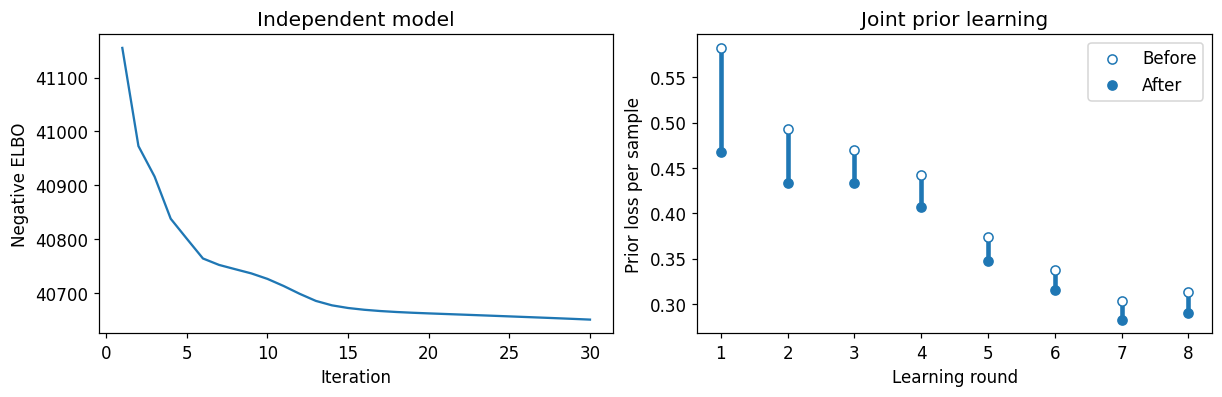

In [8]:
# Axis 0 is L. Sum the losses of its learned factor priors.
before, after = [], []
for round_record in joint.joint_sampler.learning_history:
    loading_records = round_record[0]
    before.append(sum(record["before"] for record in loading_records))
    after.append(sum(record["after"] for record in loading_records))

assert all(end <= start + 1e-10 for start, end in zip(before, after))
rounds = range(1, len(before) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
axes[0].plot(range(1, len(baseline_loss) + 1), baseline_loss)
axes[0].set(title="Independent model", xlabel="Iteration", ylabel="Negative ELBO")
axes[1].vlines(rounds, after, before, color="C0", linewidth=3)
axes[1].scatter(rounds, before, facecolors="white", edgecolors="C0", label="Before", zorder=3)
axes[1].scatter(rounds, after, color="C0", label="After", zorder=3)
axes[1].set(title="Joint prior learning", xlabel="Learning round", ylabel="Prior loss per sample")
axes[1].legend()
plt.show()

## 8. Check the sampling trace

After learning, parameters are fixed and the sampler explores the posterior.
The log joint should fluctuate: it is not an optimization curve. One apparently
stable trace is not proof of convergence.

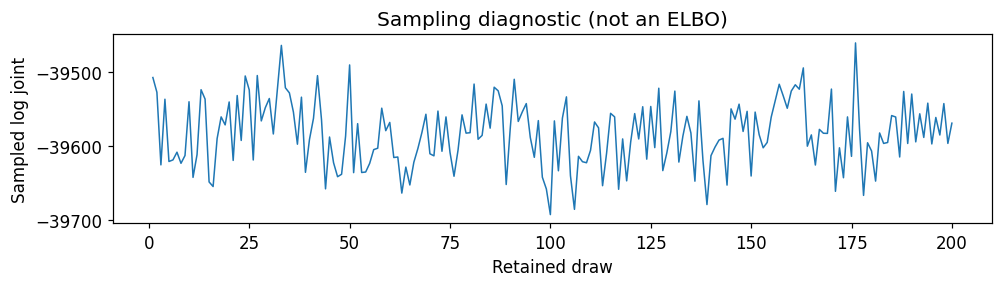

In [9]:
trace = result.joint_posterior.log_joint
plt.figure(figsize=(9, 2.5), layout="constrained")
plt.plot(range(1, len(trace) + 1), trace, linewidth=1)
plt.xlabel("Retained draw")
plt.ylabel("Sampled log joint")
plt.title("Sampling diagnostic (not an ELBO)")
plt.show()

## What to take away

Read the error table before interpreting the objective plots. On the default run,
signal recovery improves, but held-out prediction does not. Repeat with different
`SEED` values before drawing a general conclusion.

This example contains only four distinct signal profiles: root = sum of branches,
and each branch = sum of its leaves. A rank-four factorization can reconstruct the
signal without recovering the original seven programs. Also, these two fits differ
in prior family and may retain different ranks; this is not a controlled test of
conditional dependence alone.

**To try your own data:** replace the simulation and holdout cells with your
samples-by-features matrix `Y_train`, then reuse the fitting cells. Remove `S=NOISE_SD`
if the noise SD is unknown (it will be estimated during initialization). Use only
held-out RMSE when no noiseless truth is available. Fixed sample covariates can be
added as `X_l=side_information` in the joint model. This notebook learns dependencies
within one matrix; uncertain ATAC–RNA coupling needs the separate multimodal model.

For the full derivation and additional diagnostics, see
[the detailed walkthrough](tree_joint_walkthrough.ipynb).

<details>
<summary>Optional: the equation for the joint prior-learning loss</summary>

At learning round $t$, let $(L^{(m)},Z^{(m)})$ be $M$ fixed joint draws, where $Z$
indicates whether a loading is in the zero spike or Gaussian slab. The plotted loss is

$$J_t(\theta)=-\frac{1}{MN}\sum_{m=1}^M\sum_{i=1}^N\sum_{k=1}^K
\log g_{\theta k}(L_{ik}^{(m)},Z_{ik}^{(m)}\mid L_{i,<k}^{(m)}).$$

The likelihood and feature-prior terms are constant with respect to the loading-prior
parameters being updated. Thus they do not appear in this parameter-learning loss.
This is a Monte Carlo EM surrogate. Finite-chain updates do not guarantee improvement
of the observed-data marginal likelihood.

</details>